# Regulization Technique


Regularization techniques are methods used in machine learning to prevent overfitting—where a model performs well on training data but poorly on unseen data—by adding a penalty term to the loss function, which constrains model complexity and encourages simpler, more generalizable models.

 Key techniques include L1 (Lasso), L2 (Ridge), Elastic Net, dropout, and early stopping

# Lasso Regularization(L1)

this regularization technique used in feature selection using a shrinkage method also referred to as the penalized regression method.

Lasso regression magnitude of coefficients can be exactly zero

Cost function = check google

# Ridge Regularization(L2)

Ridge regression also known as L2 regularization is an extension to linear Regression that introduces term to reduze model complexity and help prevent overfitting.

Ridge regression is working value / magnitude of coefficients is almost equal to zero.

Cost function = check gfg

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [54]:
dataset = pd.read_csv("Housing.csv")
dataset.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


checking linear regression is applicable or not :  if highly corelated then applicable

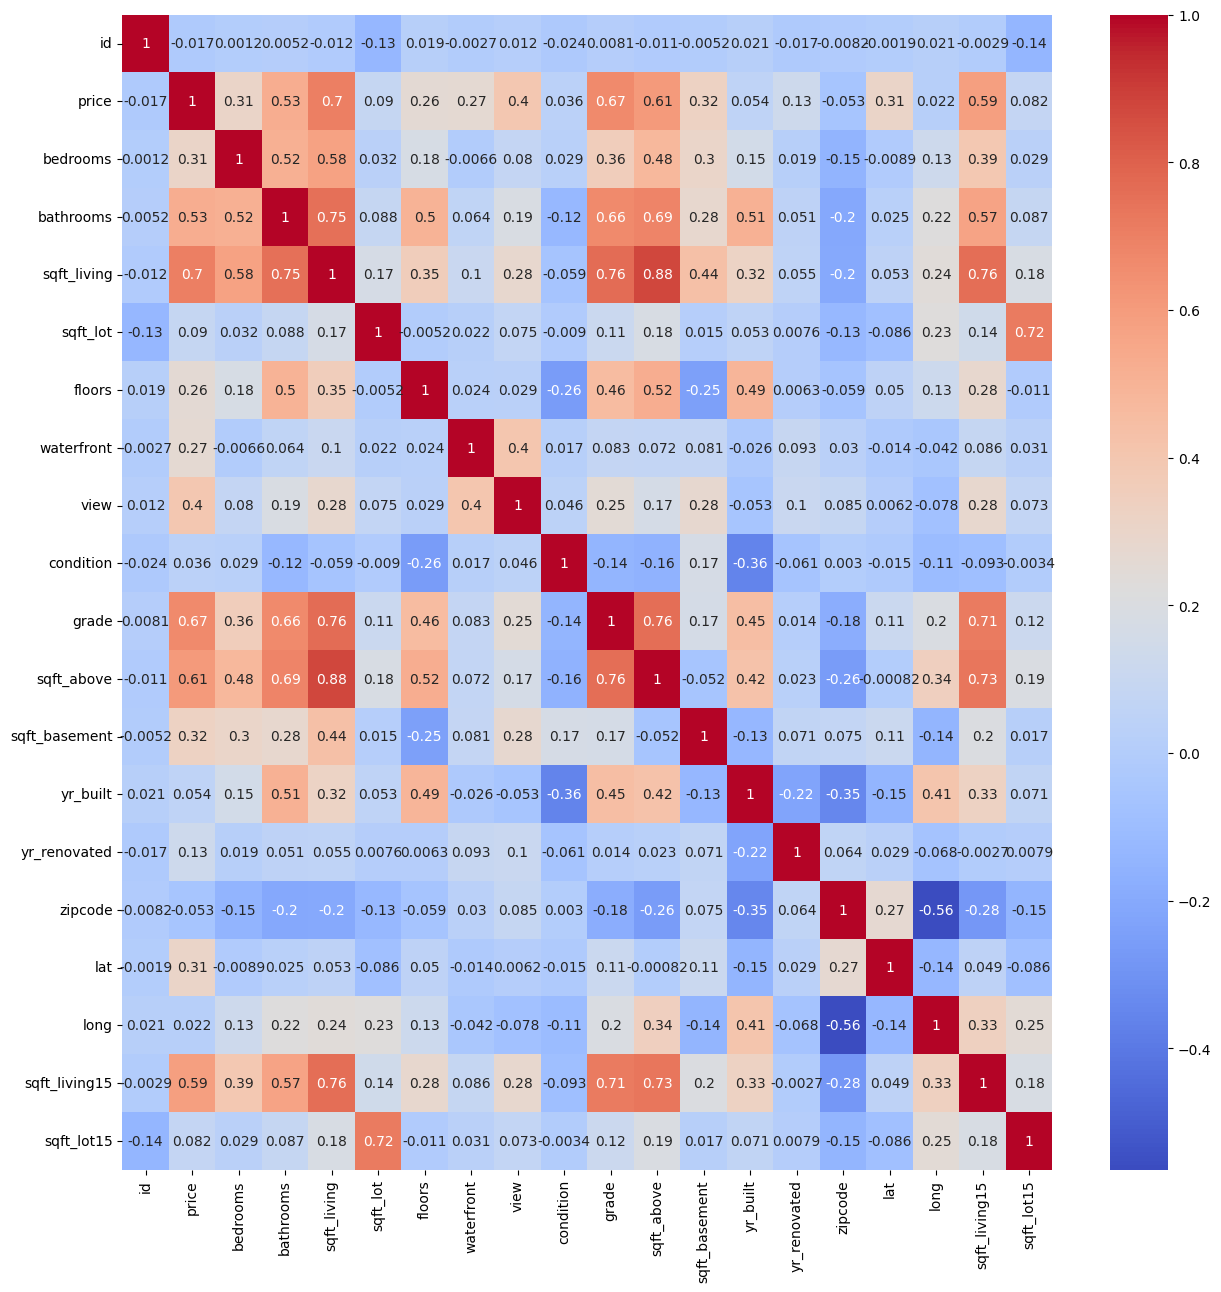

In [55]:
numeric_df = dataset.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

spliting data :

In [56]:
x = dataset.drop(columns=["id","date","price"])
y = dataset["price"]

Scalling

In [57]:
sc = StandardScaler()
sc.fit(x)

x = pd.DataFrame(sc.transform(x), columns=x.columns)
x


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,-1.473841,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.734708,-0.658681,-0.544898,-0.210128,1.870152,-0.352572,-0.306079,-0.943355,-0.260715
1,-0.398669,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.460841,0.245141,-0.681079,4.746678,0.879568,1.161568,-0.746341,-0.432686,-0.187868
2,-1.473841,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.409587,-1.229834,-0.658681,-1.293892,-0.210128,-0.933388,1.283537,-0.135655,1.070140,-0.172375
3,0.676503,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.558836,-0.891699,1.397515,-0.204446,-0.210128,1.085160,-0.283288,-1.271816,-0.914174,-0.284522
4,-0.398669,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,0.291916,-0.130895,-0.658681,0.544548,-0.210128,-0.073636,0.409550,1.199335,-0.272190,-0.192849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,-0.398669,0.500221,-0.598746,-0.337424,2.788439,-0.087173,-0.305759,-0.629187,0.291916,-0.312039,-0.658681,1.293542,-0.210128,0.468382,1.004958,-0.938069,-0.666135,-0.412381
21609,0.676503,0.500221,0.250539,-0.224386,0.936506,-0.087173,-0.305759,-0.629187,0.291916,0.629908,-0.658681,1.463768,-0.210128,1.272063,-0.356180,-1.051685,-0.228419,-0.203946
21610,-1.473841,-1.772078,-1.154047,-0.332137,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,-0.927928,-0.658681,1.293542,-0.210128,1.234683,0.247888,-0.604321,-1.410253,-0.394141
21611,-0.398669,0.500221,-0.522528,-0.307076,0.936506,-0.087173,-0.305759,-0.629187,0.291916,-0.227505,-0.658681,1.123316,-0.210128,-0.952078,-0.184414,1.028910,-0.841221,-0.420511


train test splitting

In [58]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)


Now Regularization starts :

In [59]:
from sklearn.linear_model import LinearRegression, Lasso , Ridge
from sklearn.metrics import mean_squared_error , mean_absolute_error
import numpy as np

# Linear Regression

In [60]:
lr = LinearRegression()
lr.fit(x_train,y_train)

lr.score(x_test,y_test)

0.7011905706891426

error analysis :

In [61]:
print("Mean Squared error  : ", mean_squared_error(y_test,lr.predict(x_test))) # takes input true value and predictes value
print("Mean absolute error :", mean_absolute_error(y_test , lr.predict(x_test)))
print("Root Mean Squared error :",np.sqrt(mean_squared_error(y_test,lr.predict(x_test))))


Mean Squared error  :  45173027114.563
Mean absolute error : 127493.63027966069
Root Mean Squared error : 212539.47189772304


make graph of coefficients for better understanding

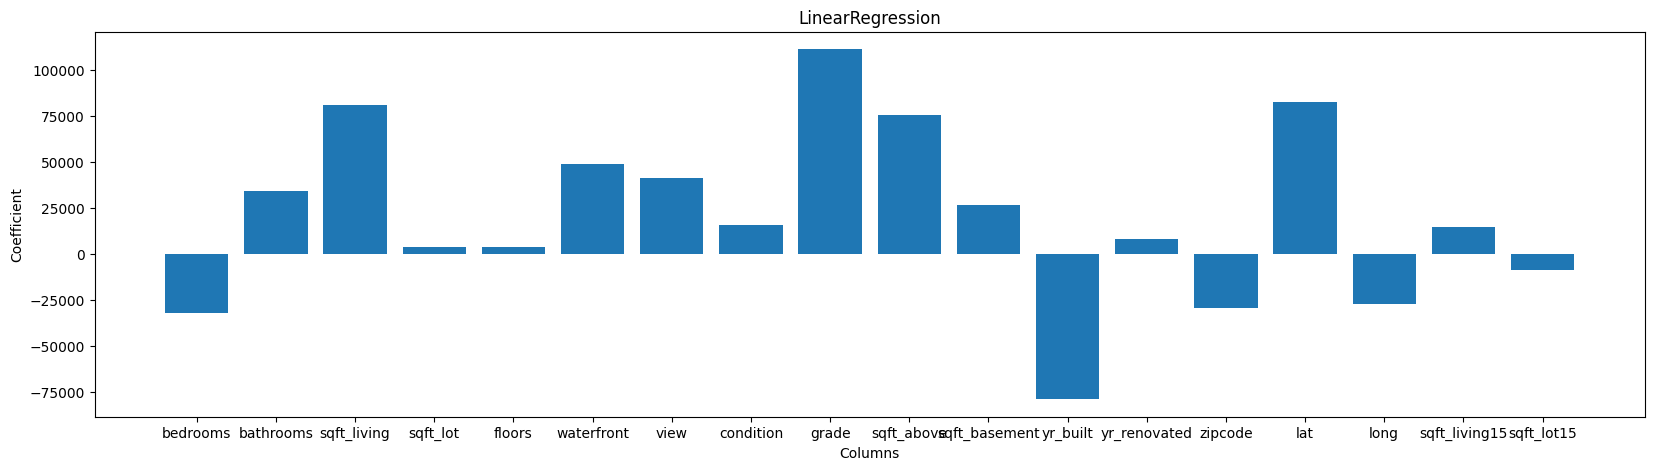

In [62]:
plt.figure(figsize=(20,5))
plt.bar(x.columns , lr.coef_)
plt.title("LinearRegression")
plt.xlabel("Columns")
plt.ylabel("Coefficient")
plt.show()

# Lasso

In [63]:
la = Lasso(alpha= 0.1) # aplha is penalty 
la.fit(x_train,y_train)

la.score(x_test,y_test)


/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.007e+13, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(


0.7011905443018992

error analysis :
 

In [64]:
print("Mean Squared error  : ", mean_squared_error(y_test,la.predict(x_test))) # takes input true value and predictes value
print("Mean absolute error :", mean_absolute_error(y_test , la.predict(x_test)))
print("Root Mean Squared error :",np.sqrt(mean_squared_error(y_test,la.predict(x_test))))


Mean Squared error  :  45173031103.699715
Mean absolute error : 127493.62994652045
Root Mean Squared error : 212539.4812821837


make graph of coefficients for better understanding


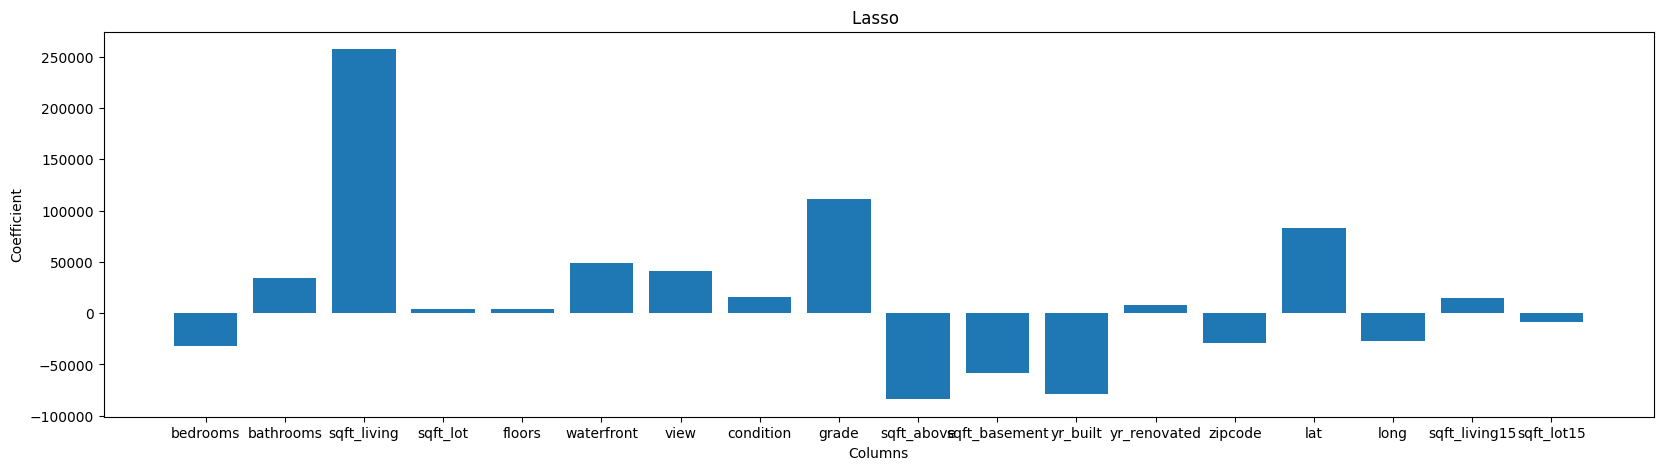

In [65]:
plt.figure(figsize=(20,5))
plt.bar(x.columns , la.coef_)
plt.title("Lasso ")
plt.xlabel("Columns")
plt.ylabel("Coefficient")
plt.show()

# Ridge

In [66]:
ri = Ridge( alpha = 10)
ri.fit(x_train,y_train)

ri.score(x_test,y_test)

0.7011729242229192

In [67]:
print("Mean Squared error  : ", mean_squared_error(y_test,ri.predict(x_test))) # takes input true value and predictes value
print("Mean absolute error :", mean_absolute_error(y_test , ri.predict(x_test)))
print("Root Mean Squared error :",np.sqrt(mean_squared_error(y_test,ri.predict(x_test))))


Mean Squared error  :  45175694849.30961
Mean absolute error : 127474.16546134405
Root Mean Squared error : 212545.7476622612


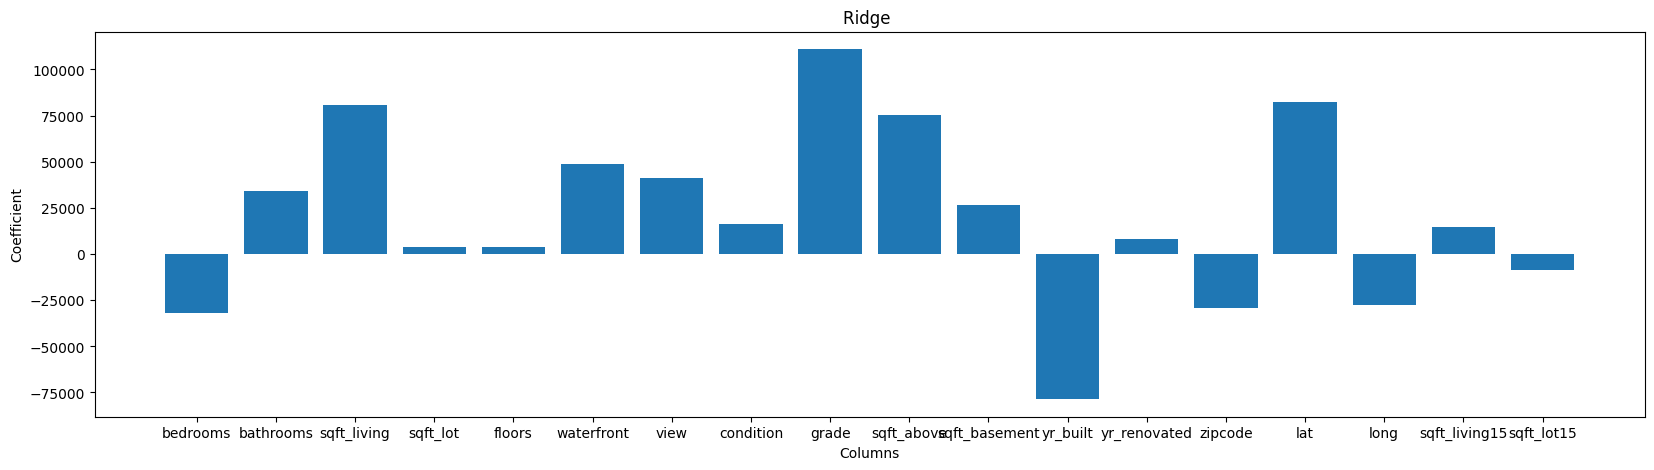

In [68]:
plt.figure(figsize=(20,5))
plt.bar(x.columns , ri.coef_)
plt.title("Ridge ")
plt.xlabel("Columns")
plt.ylabel("Coefficient")
plt.show()

Compare coefficients :

In [69]:
df = pd.DataFrame({"col_name" : x.columns , "LinearRegression" : lr.coef_ , "Lasso": la.coef_ , "Ridge" : ri.coef_ })

In [70]:
df

,col_name,LinearRegression,Lasso,Ridge
0,bedrooms,-31934.439127,-31934.323833,-31867.423534
1,bathrooms,34323.095885,34322.432038,34303.767991
2,sqft_living,80794.714025,257278.855831,80745.384239
3,sqft_lot,3680.263771,3679.884875,3681.172188
4,floors,3783.235985,3783.215458,3802.005097
5,waterfront,48657.194088,48657.117996,48635.664402
6,view,41105.519824,41105.525589,41105.828886
7,condition,15961.240920,15961.126961,15978.457259
8,grade,111156.135712,111156.396115,111032.407640
9,sqft_above,75409.106142,-83713.060686,75353.014961
